# Code for plots in Fig.1

In [2]:
# import libraries
import numpy as np
import os, sys, inspect
import matplotlib as mpl
mpl.use("Qt5Agg")
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import friedmanchisquare,ttest_1samp,spearmanr,wilcoxon
from statsmodels.stats.anova import AnovaRM
%matplotlib inline
# # import modules
currentdir = os.path.dirname(os.path.abspath(inspect.getfile(inspect.currentframe())))
parentdir = os.path.dirname(currentdir)
sys.path.insert(0,parentdir)
from behaviour import Day, Logreg_coefs
from data_import import Session
from utilities import get_property,trainingpoint_dict,get_stats_by_timecolumn,format_axs,\
normality_test,sphericity_test


## Fig 1A, 1B, 1C
Corresponding to schematics

## Fig 1D
### Cohort learning curve throughout stages 

n =  6


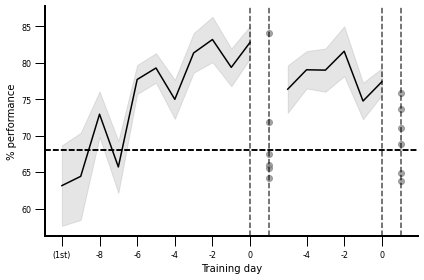

In [2]:
%matplotlib inline
def plot_learning_curve():
    stages = ['discrimination','gentest_1','categorization','gentest_2']
    # subjects that reached all stages
    sessions = Session() & 'mode="experimental"' \
        & 'stage="3"'
    subjects = get_property(sessions,'animal_id')

    nr_subjects = len(subjects)
    print('n = ',nr_subjects)
    fig, axs = plt.subplots()
    x = 0
    for i,stage in enumerate(stages):
        all_data = []
        if stage == 'discrimination':
            n_back = 10
        elif stage == 'categorization':
            n_back = 6
        elif stage.startswith('gen'):
            n_back = 1
        else:
            n_back = 1    
            
        for j,animal_id in enumerate(subjects):
            if stage.startswith('cat'):
                mode, stage_nr, _ = trainingpoint_dict['categorization_4']
            else:
                mode, stage_nr, _ = trainingpoint_dict[stage]
            entries_subject = Day() & 'mode="%s"'%mode \
            & 'stage="%i"'%stage_nr  & 'animal_id="%s"'%animal_id
            dates = entries_subject.fetch('date')
            dates = [str(d) for d in dates]
            if n_back > 0:
                ds = dates[-n_back:]
            else:
                ds = dates[:-n_back]            
            
            # for each date gather learning parameter
            data = []
            for d in ds:
                perc_correct = (Day() & 'animal_id="%s"'%animal_id \
                    & 'date="%s"'%d).fetch('performance')[0]
                data.append(perc_correct)            
            all_data.append(data)    
                
            if n_back > 0:
                new_x  = np.arange(-len(data)+1,1,1) + x + n_back-1
            else:
                new_x = np.arange(0,len(data),1) + x            
            
            if not len(data)>1:
                # for generalization test sessions
                axs.scatter(new_x.tolist(),data,color='gray',alpha= 0.7)        
        
        if n_back > 0:
            m,std = get_stats_by_timecolumn(all_data, alignment='last')
            nans = np.where(np.isnan(m))[0]
            if len(nans) != 0:
                m = m[nans[-1]:]
            m_x = np.arange(-len(m)+1,1,1) + x + n_back-1
            y_err = std/np.sqrt(nr_subjects) # sem
        else:
            m,std = get_stats_by_timecolumn(all_data, alignment='first')
            nans = np.where(np.isnan(m))[0]
            if len(nans) != 0:
                m = m[:nans[0]]
            m_x = np.arange(0,len(m),1) + x
            y_err = std/np.sqrt(nr_subjects)        
            
        if stage == 'discrimination':
            first_day_data = []
            # add 1st day of discrimination for reference
            for j,animal_id in enumerate(subjects):
                mode, stage_nr, _ = trainingpoint_dict[stage]
                entries_subject = Day() & 'mode="%s"'%mode \
                & 'stage="%i"'%stage_nr  & 'animal_id="%s"'%animal_id
                d = str(entries_subject.fetch('date')[0])
                perc_correct = (Day() & 'animal_id="%s"'%animal_id \
                    & 'date="%s"'%d).fetch('performance')[0]
                first_day_data.append(perc_correct)           
            
            m_1 = np.mean(first_day_data)
            y_err_1 = np.std(first_day_data)/np.sqrt(nr_subjects)
            m = np.hstack((m_1,m))
            y_err = np.hstack((y_err_1,y_err))
            m_x = np.hstack((m_x,m_x[-1]+1))
            x += 1        
        ymax = max([i for s in all_data for i in s])     
        ymax += 10
        var = ' % performance '
        x += abs(n_back)        
        
        axs.plot(m_x,m,'-',color='black')
        # shaded area between sem
        axs.fill_between(m_x, m - y_err, m + y_err, alpha=0.2,color='gray')        
        if i < len(stages) -1:
            axs.axvline(m_x[-1],ymin =0,ymax =ymax,linestyle='--',color='black',alpha=0.7)        
        else:
            axs.axvline(m_x[0],ymin =0,ymax =ymax,linestyle='--',color='black',alpha=0.7)
        
        axs.axhline(y=68,linestyle='--',color='black',alpha=0.7)    
    
    axs.set_xticks([0,2,4,6,8,10,13,15,17])
    axs.set_xticklabels(['(1st)','-8','-6','-4','-2','0','-4','-2','0'])
    axs.set_ylabel('%s'%var)
    axs.set_xlabel('Training day')
    axs = format_axs(axs)
    plt.tight_layout()
    plt.show()

plot_learning_curve()

## Fig 1E & S1C & S1D
### Trend of coefficients for regressors explaining trial to trial choices (logistic regression)

In [3]:
def policy_trend(training_point='discrimination'):  
    '''Coefficients from a logistic regression predicting current choices
    '''
    # subjects that have completed both generalization tests
    entries = Day() & 'mode="experimental"' \
               & 'stage="3"'
    animal_ids = get_property(entries,'animal_id')
    nr_subjects = len(animal_ids) 
    if training_point == 'discrimination':
        nr_days = 11 # min nr of common training days across subjects in discrimination
    elif training_point == 'categorization':
        nr_days = 6 # min nr of common training days across subjects in categorization
        
    nr_coefs = 5 # 5 regressors by design
    dates = [] # list of dates for each subject  
    logreg_coef = np.zeros((nr_subjects,nr_days,nr_coefs)) 
    for i,animal_id in enumerate(animal_ids):
        logreg_entries_subject = Logreg_coefs() \
            & 'analysis_type="trend"' & 'training_timepoint="%s"'%training_point \
                & 'predicted_var="choices"' & 'animal_id="%s"'%animal_id 
        dates_subject = logreg_entries_subject.fetch('dates')[0]
        nr_trials = [(Day() & 'animal_id="%s"'%animal_id \
                              & 'date="%s"'%date).fetch('nr_trials')[0] for date in dates_subject]
        complete_idx = [nr_trials[i]>90 for i in range(len(nr_trials))]
        dates_subject = list(np.array(dates_subject,dtype=object)[complete_idx])
        dates.append(dates_subject[:nr_days])
        coef_values = logreg_entries_subject.fetch('coef_values')[0]
        coef_values = coef_values[complete_idx]
        coef_names = logreg_entries_subject.fetch('coef_names')[0]
        logreg_coef[i] = coef_values[:nr_days]

    # mean for each coefficient across subjects
    mean_coef = np.mean(logreg_coef,axis=0)
    
    # standard error of mean
    std_coef = np.std(logreg_coef,axis=0) / np.sqrt(nr_subjects)
    x_days = np.arange(1,len(mean_coef)+1)
    return coef_names,logreg_coef, mean_coef, std_coef, x_days, animal_ids, dates

def plot_policy_trend(training_point='discrimination'):  
    '''Plots coeficients of logistic regression for predicted var over days of training and 
    tests statistical significant trend with Anova repeated measures'''
    
    coef_names,logreg_coef, mean_coef, std_coef, x_days,_,_  = policy_trend(training_point)
    
    # caculate ANOVAs for each of the coefficients
    nr_subjects, nr_days, nr_coefs = logreg_coef.shape
    day_id = np.tile(np.arange(nr_days), nr_subjects)
    subject_id = np.repeat(np.arange(nr_subjects), nr_days)
    
    # check assumptions of anova repeated measures
    test = 'AnovaRM'
    for c in range(nr_coefs):
        for i in range(nr_days):
            data = logreg_coef[:,i,c]
            normality=True
            try:
                normality = normality_test(data)
            except:
                pass
            if not normality:
                test = 'Friedman Rank Sum test'
                break

    # check sphericity - variances of differences must be equal in Anova
    if test == 'AnovaRM':
        for c in range(len(coef_names)):
            data = logreg_coef[:,:,c]
            sphericity = sphericity_test(data)
            if not sphericity:
                test = 'Friedman Rank Sum test'
                break
                
    p_vals_list = []
    print('n = ',nr_subjects)
    print('test: ',test)
    for c in range(len(coef_names)):
        if test == 'AnovaRM':
            data = logreg_coef[:,:,c].flatten()
            coef = {'Data':data,'Sub_id': subject_id,'cond': day_id}
            coef = pd.DataFrame.from_dict(data = coef)
            aovrm = AnovaRM(coef, depvar = 'Data',subject = 'Sub_id', within=['cond'])
            res = aovrm.fit()
            coef = res.anova_table
            p_val = np.round(res.anova_table['Pr > F'][0],10)
            print(coef_names[c] + ' '+ 'df = '+ ' '+ str(res.anova_table['Num DF'][0]) + ' ' + str(res.anova_table['Den DF'][0]), 'F = ' + ' ' + str(np.round(res.anova_table['F Value'][0],3)),'p = ' + ' '+ str(np.round(res.anova_table['Pr > F'][0],10)));
        else:
           # friedman test
           data = logreg_coef[:,:,c].T # array by days 
           assert data.shape[0] == nr_days
           stat,p_val = friedmanchisquare(*data)
           print(coef_names[c] + ' Q: '+ str(stat) + ' p= ',p_val)
        p_vals_list.append(np.round(p_val,10)) 

    # plot coefficients across training days
    fig = plt.figure(figsize = (13,4))
    for c in range(len(coef_names)):
        plt.subplot(1,len(coef_names),c+1)
        m = mean_coef[:,c]
        st = std_coef[:,c]
        plt.errorbar(x_days, m, yerr=st, fmt='o')
        plt.axhline(y=0, color='gray', linestyle='--')
        plt.ylim(-1,3)
        plt.title(coef_names[c])
        plt.xlabel('Training day')
        plt.ylabel('Coefficient')

    allaxes = fig.get_axes()
    for axs in allaxes:
        axs = format_axs(axs)
        
    # get x axis values and present only integers
    xticks = np.arange(1,len(mean_coef)+1,2)
    axs.set_xticks(xticks)
    axs.set_xticklabels([str(int(val)) for val in xticks])
    plt.tight_layout()
    plt.show()
    

DISCRIMINATION STAGE
n =  6
test:  Friedman Rank Sum test
bias Q: 11.909090909090907 p=  0.2911868000385497
previous_choices Q: 17.666666666666686 p=  0.060853651366760415
previous_outcomes Q: 13.909090909090907 p=  0.17717878724448094
previous_outcomes x previous_choices Q: 13.151515151515156 p=  0.21532341134225144
stimuli Q: 29.666666666666686 p=  0.0009710234963854786


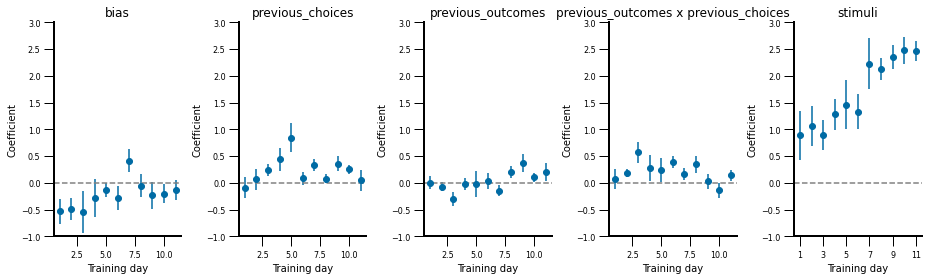

In [4]:
print('DISCRIMINATION STAGE')
plot_policy_trend(training_point='discrimination')

CATEGORIZATION STAGE
n =  6
test:  Friedman Rank Sum test
bias Q: 6.857142857142861 p=  0.2314834285914567
previous_choices Q: 1.4285714285714164 p=  0.9211625381990332
previous_outcomes Q: 2.666666666666657 p=  0.7512117103661229
previous_outcomes x previous_choices Q: 2.3809523809523796 p=  0.7943072682892635
stimuli Q: 3.809523809523796 p=  0.577152810272572


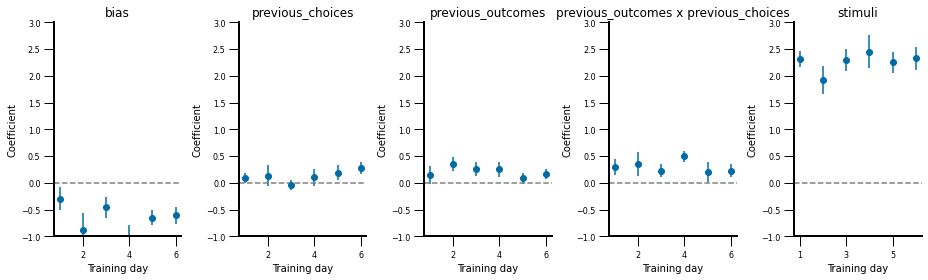

In [5]:
print('CATEGORIZATION STAGE')
plot_policy_trend(training_point='categorization')

## Fig 1F
### Correlation scatter plot of fraction of correct vs regressor coefficient group and subject-wise

In [6]:
def param_vs_coef(training_point='discrimination'):
    '''gets coefficients of logistic regression for predicted choices over days  
    for further correlation analysis'''
    
    coef_names,logreg_coef, _, _, _, animal_ids, plot_dates  = policy_trend(training_point)
    
    nr_subjects = len(animal_ids)
    nr_days = len(plot_dates[0])
    perfcorrect = np.zeros((nr_subjects,nr_days))
    bias = np.zeros((nr_subjects,nr_days))
    
    for i,animal_id in enumerate(animal_ids):
        dates = plot_dates[i]
        if training_point == 'discrimination':
            mode, stage_nr = ['periodshaping',1]
        elif training_point == 'categorization':
            mode, stage_nr = ['experimental',2]
            
        subject_sessions = Session() \
        & 'animal_id="%s"'%animal_id & 'mode="%s"'%mode & 'stage="%i"'%stage_nr
        port_layout = subject_sessions.fetch('port_layout')[0]
        day_entries = Day() & 'animal_id="%s"'%animal_id \
        & 'mode="%s"'%mode & 'stage="%i"'%stage_nr
        
        for d,date in enumerate(dates):
            date_entry = day_entries & 'date="%s"'%str(date)
            perfcorrect_day = date_entry.fetch('performance')[0]
            bias_day = date_entry.fetch('bias')[0]
            if port_layout: # correct for port assignment layout
                bias_day = -bias_day
            
            perfcorrect[i,d] = perfcorrect_day
            bias[i,d] = abs(bias_day)
        
    return coef_names, logreg_coef, animal_ids, perfcorrect, bias

def plot_param_vs_coef(training_point='discrimination'):
    '''Plots coeficients of logistic regression for choices vs performance
    - tests for significant Spearman rank correlation'''
    
    coefs,logreg_coef, animal_ids, perc_correct, _ = param_vs_coef(training_point)
    print('n = ', len(animal_ids))
    # param = locals()[parameter]
    # if correlation of entire cloud for regressor is significant
    # - compute for each subject
    for c,coef_name in enumerate(coefs):
        all_param = perc_correct.flatten()
        all_coef = logreg_coef[:,:,c].flatten()
            
        rho, p = spearmanr(all_coef, all_param)
        print('Spearman coef %s: '%coef_name,rho, ' with p-value: ',round(p,10))
        if p < 0.05:
            rho_dist = []
            p_dist = []
            for i in range(len(animal_ids)):
                p_subject = perc_correct[i]
                coef = logreg_coef[i,:,c]
                # subjects x days x coef
                coef = list(coef)
                rho_s, p_s = spearmanr(coef, p_subject)
                rho_dist.append(rho_s)
                p_dist.append(p_s)
            
            check = normality_test(rho_dist)
            if check:
                result = ttest_1samp(rho_dist, popmean=0,alternative="greater")
                print('one-sided t test for ind samples p-value: ',round(result.pvalue,8))
            else:
                result = wilcoxon(rho_dist,alternative="two-sided")
                print('one-sided wilcoxon test for ind samples p-value: ',round(result.pvalue,8))
            
            if result.pvalue < 0.05:
                print('correlation coefficient from distribution: ', np.mean(rho_dist))
        
    fig = plt.figure(figsize = (13,4))
    for c in range(len(coefs)):
        plt.subplot(1,len(coefs),c+1)
        for i in range(len(animal_ids)):
            p_subject = perc_correct[i]
            coef = logreg_coef[i,:,c]
            coef = list(coef) # subjects x days x coef
            plt.scatter(coef,p_subject)
            
        plt.title(coefs[c])
        plt.ylim(30,100)
        plt.xlabel('coefficient')
        plt.ylabel('Fraction of correct (%)')

    allaxes = fig.get_axes()
    for axs in allaxes:
        axs = format_axs(axs)
        
    plt.tight_layout()
    plt.show()

n =  6
Spearman coef bias:  0.03684529155874015  with p-value:  0.7689771704
Spearman coef previous_choices:  -0.10114189099268897  with p-value:  0.4190582332
Spearman coef previous_outcomes:  0.34202450815773294  with p-value:  0.0049412496
one-sided t test for ind samples p-value:  0.00760138
correlation coefficient from distribution:  0.34430911212107507
Spearman coef previous_outcomes x previous_choices:  -0.26054735634256987  with p-value:  0.0346096444
one-sided t test for ind samples p-value:  0.92691222
Spearman coef stimuli:  0.9741769835015114  with p-value:  0.0
one-sided t test for ind samples p-value:  1e-08
correlation coefficient from distribution:  0.9469290980597739


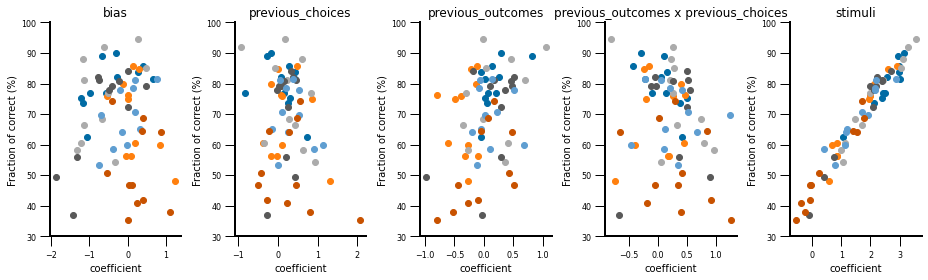

In [7]:
plot_param_vs_coef(training_point='discrimination')

n =  6
Spearman coef bias:  -0.04519119688201596  with p-value:  0.7935438327
Spearman coef previous_choices:  -0.26895843386476165  with p-value:  0.1126975216
Spearman coef previous_outcomes:  0.009527488801336699  with p-value:  0.9560200361
Spearman coef previous_outcomes x previous_choices:  -0.1123986178860397  with p-value:  0.5139726677
Spearman coef stimuli:  0.8682889794083066  with p-value:  0.0
one-sided t test for ind samples p-value:  1.49e-06
correlation coefficient from distribution:  0.7959683127569096


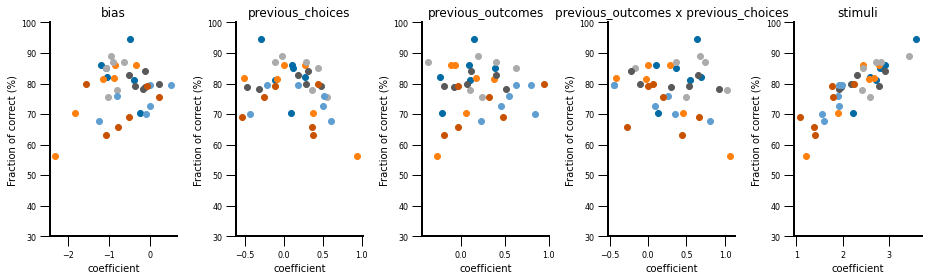

In [8]:
plot_param_vs_coef(training_point='categorization')